In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 检查是否有 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')

使用设备: cpu


In [2]:
# 定义数据预处理：将图像转换为张量并归一化到 [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST 的均值和标准差
])

# 下载训练集
trainset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# 下载测试集
testset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# 创建数据加载器
batch_size = 64
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=batch_size, shuffle=False
)

print(f'训练集大小: {len(trainset)}')
print(f'测试集大小: {len(testset)}')
print(f'一个 batch 的形状: {next(iter(trainloader))[0].shape}')

100.0%
100.0%
100.0%
100.0%

训练集大小: 60000
测试集大小: 10000
一个 batch 的形状: torch.Size([64, 1, 28, 28])


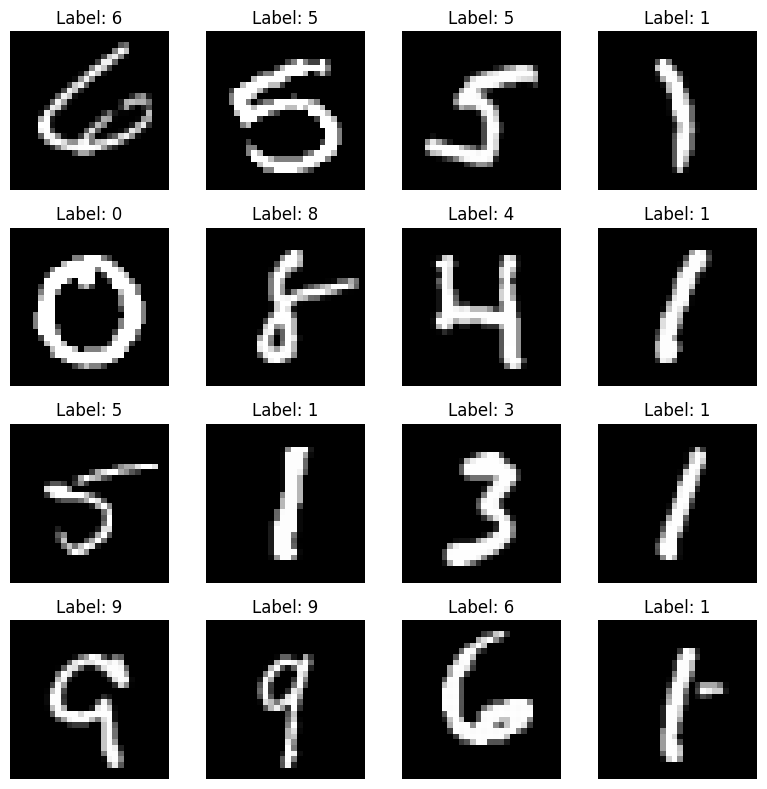

In [3]:
# 显示前 16 张图片
def show_images():
    images, labels = next(iter(trainloader))
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i][0], cmap='gray')
        ax.set_title(f'Label: {labels[i]}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_images()

In [4]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_size=128, num_classes=10):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # 将图像展平：从 (batch, 1, 28, 28) 变成 (batch, 784)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# 创建模型实例
model = MLP().to(device)
print(model)

MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [5]:
criterion = nn.CrossEntropyLoss()  # 交叉熵损失，适合多分类
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam 优化器

In [6]:
def train_one_epoch():
    model.train()  # 设置为训练模式
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in trainloader:
        # 将数据移到 GPU（如果可用）
        images, labels = images.to(device), labels.to(device)

        # 梯度清零
        optimizer.zero_grad()

        # 前向传播
        outputs = model(images)
        loss = criterion(outputs, labels)

        # 反向传播
        loss.backward()

        # 更新参数
        optimizer.step()

        # 统计
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(trainloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

In [7]:
def evaluate():
    model.eval()  # 设置为评估模式
    correct = 0
    total = 0

    with torch.no_grad():  # 不计算梯度，节省内存
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

Epoch [1/10]
  Train Loss: 0.0366, Train Acc: 98.88%
  Test Acc: 97.56%

Epoch [2/10]
  Train Loss: 0.0307, Train Acc: 99.00%
  Test Acc: 97.30%

Epoch [3/10]
  Train Loss: 0.0267, Train Acc: 99.10%
  Test Acc: 97.30%

Epoch [4/10]
  Train Loss: 0.0216, Train Acc: 99.30%
  Test Acc: 97.69%

Epoch [5/10]
  Train Loss: 0.0196, Train Acc: 99.33%
  Test Acc: 97.48%

Epoch [6/10]
  Train Loss: 0.0167, Train Acc: 99.42%
  Test Acc: 97.62%

Epoch [7/10]
  Train Loss: 0.0156, Train Acc: 99.47%
  Test Acc: 97.39%

Epoch [8/10]
  Train Loss: 0.0134, Train Acc: 99.53%
  Test Acc: 97.67%

Epoch [9/10]
  Train Loss: 0.0126, Train Acc: 99.58%
  Test Acc: 97.28%

Epoch [10/10]
  Train Loss: 0.0113, Train Acc: 99.61%
  Test Acc: 97.62%



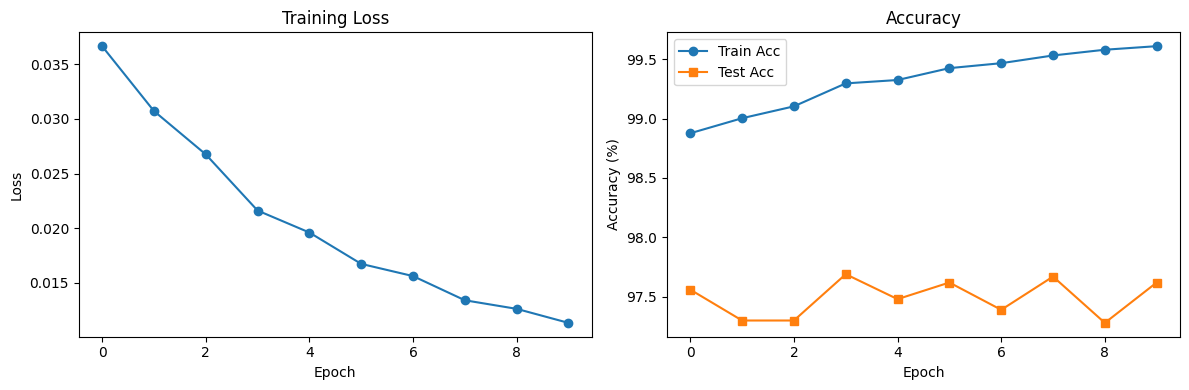

In [9]:
num_epochs = 10
train_losses = []
train_accs = []
test_accs = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch()
    test_acc = evaluate()

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}]')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Test Acc: {test_acc:.2f}%')
    print()

# 绘制损失和准确率曲线
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, marker='o')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(train_accs, label='Train Acc', marker='o')
ax2.plot(test_accs, label='Test Acc', marker='s')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.show()